In [2]:
import torch
import torch.nn as nn

In [3]:
from GPT_Model import GPT,generate_text,cfg,tokenizer,text_to_token_id,token_id_to_text

In [4]:
cfg["context_len"]=int(cfg["context_len"]/4)
cfg

{'vocab': 50257,
 'context_len': 256,
 'emb_dim': 768,
 'n_head': 12,
 'n_layer': 12,
 'dropout': 0.1,
 'qkv_bias': False}

In [5]:
with open("the-verdict.txt",'r') as file:
  text=file.read()
# with open("/content/drive/MyDrive/Colab_Notebooks/the-verdict.txt",'r') as file:
#   text=file.read()

In [6]:
total_characters = len(text)
total_tokens = len(tokenizer.encode(text))

print(f"Characters: {total_characters}\nTokens: {total_tokens}")

Characters: 20479
Tokens: 5145


In [7]:
import tiktoken
from torch.utils.data import Dataset, DataLoader

In [8]:
class GPTdataset(Dataset):
    def __init__(self, txt, tokenizer, max_length, stride):
        self.input_ids =[]
        self.target_ids = []

        token_ids = tokenizer.encode(txt, allowed_special={'<|endoftext|>'})

        for i in range(0, len(token_ids)-max_length, stride):
            input_chunk = token_ids[i:i+max_length]
            target_chunk = token_ids[i+1: i+max_length+1]
            self.input_ids.append(torch.tensor(input_chunk))
            self.target_ids.append(torch.tensor(target_chunk))

    def __len__(self):
        return len(self.input_ids)

    def __getitem__(self, index):
        return self.input_ids[index], self.target_ids[index]


In [9]:
len(text)

20479

In [12]:
train_ratio=.8
n=len(text)
train_data=text[:int(n*train_ratio)]
val_data=text[int(n*train_ratio)+1:]
print(len(train_data),len(val_data))

16383 4095


In [13]:
def createdataloader(txt,batch_size,max_len,stride,shuffle=True,drop_last=True,num_worker=0):
  tokenizer=tiktoken.get_encoding("gpt2")
  dataset=GPTdataset(txt,tokenizer,max_len,stride)
  dataloader=DataLoader(
    dataset=dataset,
    batch_size=batch_size,
    shuffle=shuffle,
    drop_last=drop_last,
    num_workers=num_worker
  )
  return dataloader

In [14]:
train_loader = createdataloader(
    txt=train_data,
    batch_size=2,
    max_len=cfg["context_len"],
    stride=cfg["context_len"],
    drop_last=True,
    shuffle=True,
    num_worker=0
)


In [15]:
val_data

'\n\n"Once, when I looked up, I seemed to see a smile behind his close grayish beard--as if he had the secret, and were amusing himself by holding it back from me. That exasperated me still more. The secret? Why, I had a secret worth twenty of his! I dashed at the canvas furiously, and tried some of my bravura tricks. But they failed me, they crumbled. I saw that he wasn\'t watching the showy bits--I couldn\'t distract his attention; he just kept his eyes on the hard passages between. Those were the ones I had always shirked, or covered up with some lying paint. And how he saw through my lies!\n\n"I looked up again, and caught sight of that sketch of the donkey hanging on the wall near his bed. His wife told me afterward it was the last thing he had done--just a note taken with a shaking hand, when he was down in Devonshire recovering from a previous heart attack. Just a note! But it tells his whole history. There are years of patient scornful persistence in every line. A man who had s

In [16]:
val_loader=createdataloader(
     txt=val_data,
    batch_size=2,
    max_len=cfg["context_len"],
    stride=cfg["context_len"],
    drop_last=True,
    shuffle=True,
    num_worker=0
)

In [14]:
# CHECK IF TOTAL TOKENS IS NOT LESS THAN CONTEXT SIZE

if total_tokens*train_ratio < cfg["context_len"]/4:
    print("NOT ENOUGH TOKENS FOR THE TRAINING LOADER")

if total_tokens*(1-train_ratio) < cfg["context_len"]/4:
    print("NOT ENOUGH TOKENS FOR THE VALIDATION LOADER")

In [15]:
print("Train Loader")
for x,y in train_loader:
    print(x.shape,y.shape)

print("\nValidation Loader")
for x,y in val_loader:
    print(x.shape, y.shape)


print("Train Loader Len: ", len(train_loader))
print("Valid Loader Len: ", len(val_loader))

Train Loader
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])

Validation Loader
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
Train Loader Len:  8
Valid Loader Len:  2


In [16]:
def calc_loss_batch(input_batch, target_batch, model, device):
    input_batch, target_batch = input_batch.to(device), target_batch.to(device)
    logits = model(input_batch)
    loss = torch.nn.functional.cross_entropy(logits.flatten(0,1), target_batch.flatten())
    return loss

def calc_loss_loader(data_loader, model, device, num_batches=None):
    total_loss = 0.

    if len(data_loader) == 0:
        return float("nan")
    elif num_batches is None:
        num_batches = len(data_loader)
    else:
        num_batches = min(num_batches, len(data_loader))

    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i<num_batches:
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            total_loss+=loss.item()

        else:
            break

    return total_loss/num_batches


In [17]:
torch.manual_seed(123)
model = GPT(cfg)
model.eval()

print("Model Loaded in eval Mode|")

Model Loaded in eval Mode|


In [18]:
torch.cuda.is_available()

True

In [19]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# device = "cpu"
print(f"Device: {device}")
model.to(device)

torch.manual_seed(123)

with torch.no_grad():
    train_loss = calc_loss_loader(train_loader, model, device)
    val_loss = calc_loss_loader(val_loader, model, device)

print(f"Training Loss= {train_loss}\nValidation Loss= {val_loss}")

Device: cuda
Training Loss= 10.995346188545227
Validation Loss= 11.002695083618164


## Pretraining LOOP

In [20]:
def text_to_token_id(text, tokenizer):
    encoded = tokenizer.encode(text)
    encoded_tensor = torch.tensor(encoded).unsqueeze(0)  # adds batch dimension
    return encoded_tensor

def token_id_to_text(token_ids, tokenizer):
    text_batch = []
    for i in range(len(token_ids)):
        text = tokenizer.decode(token_ids[i].tolist())
        text_batch.append(text)
    return text_batch


In [21]:
def evaluate_model(model,train_loader,val_loader,device,eval_iter):
  model.eval()
  with torch.no_grad():
    train_loss = calc_loss_loader(train_loader, model, device,num_batches=eval_iter)
    val_loss = calc_loss_loader(val_loader, model, device,num_batches=eval_iter)

    model.train()
    return train_loss,val_loss

In [22]:
def generate_and_print_sample(model, tokenizer, device, start_context):
    model.eval()
    context_size = cfg["context_len"]
    encoded = text_to_token_id(start_context, tokenizer).to(device)  # plain string, no list
    
    with torch.no_grad():
        token_ids = generate_text(
            model=model, ip_token_id=encoded, max_new_tokens=50, context_size=context_size
        )
    
    decoded_text = token_id_to_text(token_ids, tokenizer)
    print(decoded_text[0].replace("\n", " "))
    model.train()

In [23]:
def train_model_simple(model, train_loader, val_loader, optimizer, device, num_epochs, eval_freq, eval_iter, start_context, tokenizer):
    train_losses, val_losses, track_tokens_seen = [], [], []
    tokens_seen, global_step = 0, -1

    for epoch in range(num_epochs):
        model.train()

        for input_batch, target_batch in train_loader:  # ← inner loop
            optimizer.zero_grad()
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            loss.backward()
            optimizer.step()
            tokens_seen += input_batch.numel()
            global_step += 1

            if global_step % eval_freq == 0:
                train_loss, val_loss = evaluate_model(model, train_loader, val_loader, device, eval_iter)
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                track_tokens_seen.append(tokens_seen)
                print(f"Epoch: {epoch+1} (step: {global_step}): Train_Loss={train_loss}, Val_Loss={val_loss}")


        print("\n####################################\n")
        print(f"Epoch {epoch+1} sample output")
        generate_and_print_sample(model, tokenizer, device, start_context)
        print("\n####################################\n")

    return train_losses, val_losses, track_tokens_seen

In [24]:
train_loader

In [25]:
import time
start_time=time.time()

torch.manual_seed(123)
model=GPT(cfg)
model.to(device=torch.device("cuda" if torch.cuda.is_available() else "cpu"))
# model.to(device=torch.device("cpu"))

optimizer=torch.optim.AdamW(model.parameters(),lr=0.005,weight_decay=0.1)

epochs=100
train_losses,val_losses,track_tokens_seen=train_model_simple(model, train_loader, val_loader, optimizer, device, num_epochs=epochs, eval_freq=5, eval_iter=10, start_context="Every effort moves you", tokenizer=tokenizer)
end_time = time.time()

print("Execution time: ", (end_time-start_time)/60, "minutes")

Epoch: 1 (step: 0): Train_Loss=9.480928421020508, Val_Loss=9.559942722320557
Epoch: 1 (step: 5): Train_Loss=8.259562075138092, Val_Loss=8.635027408599854

####################################

Epoch 1 sample output
Every effort moves you the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the

####################################

Epoch: 2 (step: 10): Train_Loss=7.077763915061951, Val_Loss=8.917598724365234
Epoch: 2 (step: 15): Train_Loss=6.415598630905151, Val_Loss=8.798291206359863

####################################

Epoch 2 sample output
Every effort moves you                                                  

####################################

Epoch: 3 (step: 20): Train_Loss=6.439705908298492, Val_Loss=9.221061706542969

####################################

Epoch 3 sample output
Every effort moves you                                 

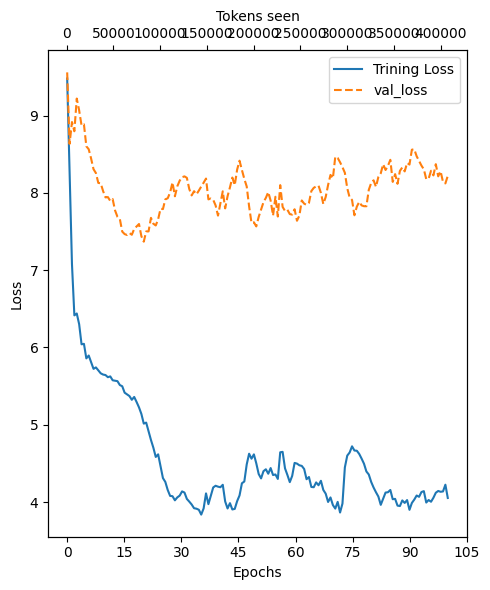

In [27]:
import matplotlib.pylab as plt
from matplotlib.ticker import MaxNLocator

def plotlosses(epochs,token_seen,train_losses,val_losses):
  fig,ax=plt.subplots(figsize=(5,6))

  ax.plot(epochs,train_losses,label="Trining Loss")
  ax.plot(epochs,val_losses,linestyle="--",label="val_loss")
  ax.set_xlabel("Epochs")
  ax.set_ylabel("Loss")
  ax.legend(loc="upper right")
  ax.xaxis.set_major_locator(MaxNLocator(integer=True))

  ax2 = ax.twiny()
  ax2.plot(token_seen, train_losses, alpha=0)
  ax2.set_xlabel("Tokens seen")

  fig.tight_layout()
  plt.savefig("loss-plot.pdf")
  plt.show()


epochs_tensor = torch.linspace(0, epochs, len(train_losses))
plotlosses(epochs_tensor, track_tokens_seen, train_losses, val_losses)

##  Save the model

In [ ]:
torch.save(
  {"model_state_dict":model.state_dict(),
   "optimzer_state_dict":optimizer.state_dict()
   },
  "model_and_optimizer.pth"
  )

## Load the Model

In [21]:
checkpoint=torch.load("model_and_optimizer.pth")

model=GPT(cfg)
model.load_state_dict(checkpoint["model_state_dict"])

optimizer=torch.optim.AdamW(model.parameters(),lr=5e-4,weight_decay=0.1)
optimizer.load_state_dict(checkpoint["optimzer_state_dict"])

model.train()

GPT(
  (token_emb): Embedding(50257, 768)
  (pos_emb): Embedding(256, 768)
  (dropout): Dropout(p=0.1, inplace=False)
  (tranformer_block): Sequential(
    (0): Transfomers(
      (layernorm): LayerNorm()
      (mutihead_atten): MultiHeadAttention(
        (w_query): Linear(in_features=768, out_features=768, bias=False)
        (w_key): Linear(in_features=768, out_features=768, bias=False)
        (w_value): Linear(in_features=768, out_features=768, bias=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (dropout): Dropout(p=0.1, inplace=False)
      (feed_forward): FeedForward(
        (layer): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
    )
    (1): Transfomers(
      (layernorm): LayerNorm()
      (mutihead_atten): MultiHeadAttention(
        (w_q

## Generating text

In [22]:
tokenid=generate_text(
  model=model,
  ip_token_id=text_to_token_id("Every step moves you",tokenizer),
  max_new_tokens=6,
  context_size=int(cfg["context_len"]/4)
)
print(token_id_to_text(tokenid,tokenizer))

['E"? had"?\n mourntable', 'v\n fond apparent often height should', 'e\n fond often theagged G', 'r"?\ni G (ense', 'y\n fond often the oftentable', ' --BeBeBe\n endless', 's\n G often beauty Carlo.', 't INever. queer failed Gallery', 'e\nPoor often often often often', 'p"?. ThMr before when', ' "?Be\n G absurditytable', 'm\n G resolve sav heightking', 'o.d Mr jealousy would found', 'v and\n G G res often', 'e"?Be\ndhum often', 's the\n circulation circulation res endless', '  stopped\n circulation circulation res should', 'yBeBe\n, asd', 'o\nPoor height circulationaming Mr', 'u\n circulation restableuation res']


## Generating text with Temp as in (13.Temperature_scaling)

In [24]:
def generate_text_with_temp(model,ip_token_id,max_new_tokens,context_size,temp):
  for i in range(max_new_tokens):
    context_ip=ip_token_id[:,-context_size:]
    with torch.no_grad():
      logit=model(context_ip)
    logit=logit[:,-1,:] #tensor size is (batch) x 1 x (vocab_size) 
    
    logit=logit/temp
        

    prob=torch.softmax(logit,dim=-1)#convert to prob , we can take max of logit also that give same but prob give explainibilty
    idx_next=torch.argmax(prob,dim=-1,keepdim=True) #taking max val prob
    ip_token_id=torch.concat((ip_token_id,idx_next),dim=1)
  return ip_token_id  

In [25]:
tokenid=generate_text_with_temp(
  model=model,
  ip_token_id=text_to_token_id("Every step moves back",tokenizer),
  max_new_tokens=60,
  context_size=int(cfg["context_len"]/4),
  temp=3
)
print(token_id_to_text(tokenid,tokenizer))

['E\n circulation often height sav often height res often often, problem which often the often of the tone set height aspl set paintingtable appointed Carlo Thocation resial wife height and led often ofented height the beauty easetable height hear hear own similartable, absurdityocation. led oddly the couple the the', 'v\n\nPoor often often res, when which Carlotable and res Carlo"?,,ributespl vill height easeeven hear the hear, on the the the often the often set often st as put set height oftenthough, the hear res, as appointed. Gideon. Th the putdking similar I', 'e\n should res Totable height height apparent exquisitetable often often Carlo oftentable often sav absurdity ease often height ease. led resolve heightdd dragged the height often often apparent height absurditytable endless apparent height often apparent oftentable Gdines Mr res-- Gallerycheontable Carlo ofteneven apparent apparent put ease', 'r\n fond often circulation bal often height resdthough height ease--table Carlo 

## Generating text with topk scaling as in (14.Top_k_scaling)


In [32]:
def generate_text_simple_with_temp_and_topk(model, ip_token_id, max_new_tokens, context_size, temp=1.0, topk=None):
    for i in range(max_new_tokens):
        context_ip = ip_token_id[:, -context_size:]
        
        with torch.no_grad():
            logit = model(context_ip)
        
        logit = logit[:, -1, :]  # (batch, vocab_size)
        
        if topk is not None:
            top_logit, _ = torch.topk(logit, topk)
            logit = torch.where(
                condition=logit < top_logit[:, [-1]],  # ← [:, [-1]] keeps shape (batch, 1) for broadcasting
                input=torch.tensor(float("-inf")).to(logit.device),
                other=logit
            )
        
        if temp is not None and temp > 0.0:
            logit = logit / temp  # scale before softmax
        
        prob = torch.softmax(logit, dim=-1)
        idx_next = torch.multinomial(prob, num_samples=1)  # ← use multinomial for temperature sampling
        ip_token_id = torch.cat((ip_token_id, idx_next), dim=1)
    
    return ip_token_id

In [ ]:
#temp+topk implemention to find next token generation
tokenid=generate_text_simple_with_temp_and_topk(
  model=model,
  ip_token_id=text_to_token_id("Every step moves you",tokenizer),
  max_new_tokens=6,
  context_size=int(cfg["context_len"]/4),
  temp=0.5,
  topk=3
)
print(token_id_to_text(tokenid,tokenizer))

['E\n G absurditytable Carlo res', 'v\n Gtable circulationtable resolve', 'e were. suddenly Th lips as', 'r. Gallery H Mr!"ines', 'yBeBe\n height height height', ' "?. queer Tha\n', 's the--\n circulation circulation often', 't Th I-- Th fashionable had', 'e"? asBeBeBe dissatisfied', 'p\nPoor oftenaming apparent often', ' "?.denteddfor', 'm\n G res circulation Carlotable', 'o. Th H. Gideon Th', 'v"?Be. queer academic Gideon', 'e. Th suddenlyd academicd', 's--BeMr led"? I', ' "?OhBeBeBe\n', 'y\ntable often often often often', 'o reflected. twenty Th Gallery\n', 'u Rick\n lun circulation res res']


In [35]:
#temp+topk implemention to find next token generation
tokenid=generate_text_simple_with_temp_and_topk(
  model=model,
  ip_token_id=text_to_token_id("Every step moves you",tokenizer),
  max_new_tokens=6,
  context_size=int(cfg["context_len"]/4),
  temp=1,
  topk=5
)
print(token_id_to_text(tokenid,tokenizer))

['E as asNever\n. (', 'v IMoon. twenty endless stopped', 'e as\n res Th bal res', 'r"?plOhComeBe.', 'ycolourulations. Rick thei', '  and\n\n G res inc', 's and--Never. neg\n', 't\nPoor sav (table often', 'e he.d Gideon Th the', 'pcolour\nPoor apparent res res', '  hepl v Th Gallery Had', 'm"?BeBe the\n great', 'o IBe\n"-- hear', 'v reflected and".dMy', 'eBecolourBe I, and', 's failed. led"? lips Th', '  Th the. Th GalleryOh', 'y\n\n circulationamingbreeding bas', 'o\n fondtable circulationtable--', 'u\nPoor often fond often should']
